# Exploring Multi-view Symbolic Regression methods in physical sciences

**Paper:** Russeil, E., de Franca, F. O., Malanchev, K., Moinard, G., & Cherrey, M. (2025). *Exploring Multi-view Symbolic Regression methods in physical sciences.* Philosophical Transactions of the Royal Society A.

**Carpeta origen:** `Papers/05_Benchmarks_y_Datasets/Multiview_Symbolic_Regression_Physical_Sciences.pdf`

## Que se reproduce en este cuaderno

Cuando se dispone de **varios conjuntos de datos relacionados** que comparten la misma forma funcional pero con parametros distintos (p. ej., la misma ley fisica medida en distintos experimentos, cada uno con muy pocos puntos), ajustar cada conjunto **por separado** desperdicia la informacion compartida entre ellos y produce estimaciones inestables cuando hay pocos datos por experimento. La Regresion Simbolica Multi-Vista (MvSR) busca una **unica estructura funcional compartida**, permitiendo que solo los parametros numericos varien entre "vistas" (experimentos).

Reproducimos este principio con un ejemplo directo: 6 "experimentos" que siguen la misma ley de potencias $y=k_i\cdot x^{n}$ (p. ej., la energia de 6 muelles con distinta constante elastica $k_i$ pero el mismo exponente $n=2$ propio de la fisica del fenomeno), con solo **4 puntos ruidosos por experimento** -- deliberadamente pocos. Comparamos:

1. **Ajuste independiente:** cada experimento ajustado por separado (4 puntos, 2 parametros libres cada uno -- muy poco margen).
2. **Ajuste multi-vista:** los 6 experimentos ajustados **conjuntamente**, compartiendo un unico exponente $n$ pero permitiendo que cada $k_i$ sea propio de su experimento -- exactamente el diseno de MvSR.

## Repositorio publico

El paper compara implementaciones existentes (`Operon`, `PySR` -- ya usado en un cuaderno anterior de esta coleccion --, `PhySO` -- tambien reproducido en esta coleccion -- y `eggp`) en su modo multi-vista, sin introducir una herramienta de codigo propia bajo un nombre nuevo. Reimplementamos aqui, desde cero con `scipy.optimize.least_squares`, el principio de optimizacion conjunta con parametros compartidos y parametros propios de cada vista que subyace a todas esas implementaciones.

In [1]:
%pip install -q numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Seis experimentos, la misma ley, muy pocos puntos cada uno

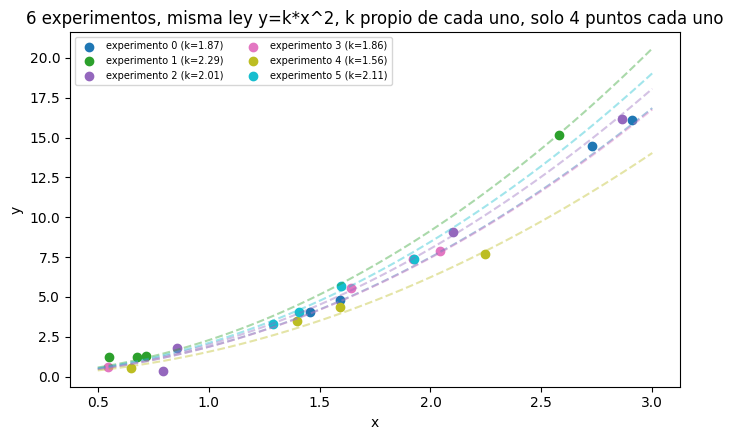

In [2]:
import numpy as np
from scipy.optimize import curve_fit, least_squares
import matplotlib.pyplot as plt

np.random.seed(0)

n_true = 2.0
n_experiments = 6
k_true = np.random.uniform(0.5, 3.0, n_experiments)
n_points_per_exp = 4  # deliberadamente muy pocos puntos (apenas mas que los 2 parametros libres por experimento)

experiments = []
for i in range(n_experiments):
    x = np.random.uniform(0.5, 3.0, n_points_per_exp)
    y = k_true[i] * x ** n_true + np.random.normal(0, 0.35, n_points_per_exp)
    experiments.append((x, y))

fig, ax = plt.subplots(figsize=(7, 4.5))
x_line = np.linspace(0.5, 3.0, 100)
colors = plt.cm.tab10(np.linspace(0, 1, n_experiments))
for i, (x, y) in enumerate(experiments):
    ax.scatter(x, y, color=colors[i], label=f'experimento {i} (k={k_true[i]:.2f})')
    ax.plot(x_line, k_true[i] * x_line ** n_true, '--', color=colors[i], alpha=0.4)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'6 experimentos, misma ley y=k*x^{n_true:.0f}, k propio de cada uno, solo {n_points_per_exp} puntos cada uno')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 2. Ajuste independiente (cada experimento por separado)

In [3]:
def power_law(x, k, n):
    return k * x ** n

independent_n = []
for i, (x, y) in enumerate(experiments):
    popt, _ = curve_fit(power_law, x, y, p0=[1.0, 1.0], maxfev=5000)
    independent_n.append(popt[1])
    print(f'  experimento {i}: n_estimado = {popt[1]:.3f}   (verdad: {n_true})')

mean_n = np.mean(independent_n)
std_n = np.std(independent_n)
print(f'\nMedia de los exponentes estimados por separado: {mean_n:.4f}  (desviacion estandar: {std_n:.4f})')
print(f'Error absoluto de la media: {abs(mean_n - n_true):.4f}')

  experimento 0: n_estimado = 2.013   (verdad: 2.0)
  experimento 1: n_estimado = 1.836   (verdad: 2.0)
  experimento 2: n_estimado = 2.004   (verdad: 2.0)
  experimento 3: n_estimado = 1.780   (verdad: 2.0)
  experimento 4: n_estimado = 1.768   (verdad: 2.0)
  experimento 5: n_estimado = 1.905   (verdad: 2.0)

Media de los exponentes estimados por separado: 1.8843  (desviacion estandar: 0.0984)
Error absoluto de la media: 0.1157


## 3. Ajuste multi-vista: un exponente compartido, constantes propias

Optimizamos simultaneamente sobre los **24 puntos combinados** de los 6 experimentos, con un unico parametro $n$ compartido y 6 parametros $k_i$ independientes -- el mismo tipo de optimizacion conjunta de minimos cuadrados no lineales que usan las herramientas multi-vista reales.

In [4]:
def multiview_residuals(params, experiments):
    n = params[0]
    ks = params[1:]
    res = []
    for k, (x, y) in zip(ks, experiments):
        res.append(k * x ** n - y)
    return np.concatenate(res)

x0 = [1.0] + [1.0] * n_experiments
result = least_squares(multiview_residuals, x0, args=(experiments,))
n_multiview = result.x[0]
k_multiview = result.x[1:]

print(f'Exponente compartido estimado (multi-vista): n = {n_multiview:.4f}   (verdad: {n_true})')
print(f'Error absoluto: {abs(n_multiview - n_true):.4f}')
print('\nConstantes k_i estimadas vs. verdad:')
for i in range(n_experiments):
    print(f'  experimento {i}: k_estimado={k_multiview[i]:.3f}   k_verdad={k_true[i]:.3f}')

Exponente compartido estimado (multi-vista): n = 1.9429   (verdad: 2.0)
Error absoluto: 0.0571

Constantes k_i estimadas vs. verdad:
  experimento 0: k_estimado=2.029   k_verdad=1.872
  experimento 1: k_estimado=2.409   k_verdad=2.288
  experimento 2: k_estimado=2.103   k_verdad=2.007
  experimento 3: k_estimado=2.038   k_verdad=1.862
  experimento 4: k_estimado=1.657   k_verdad=1.559
  experimento 5: k_estimado=2.120   k_verdad=2.115


## 4. Comparacion

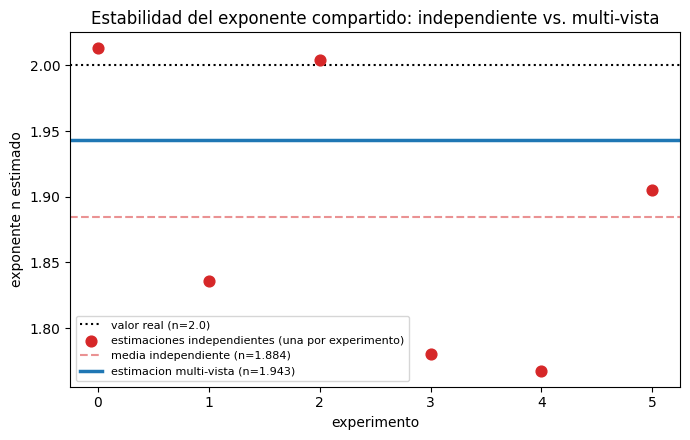

Error absoluto en n:
  Ajuste independiente (media de los 6): 0.1157
  Ajuste multi-vista (un solo n compartido): 0.0571


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(n_true, color='black', linestyle=':', label=f'valor real (n={n_true})')
ax.scatter(range(n_experiments), independent_n, color='tab:red', s=60, zorder=5, label='estimaciones independientes (una por experimento)')
ax.axhline(mean_n, color='tab:red', linestyle='--', alpha=0.5, label=f'media independiente (n={mean_n:.3f})')
ax.axhline(n_multiview, color='tab:blue', linewidth=2.5, label=f'estimacion multi-vista (n={n_multiview:.3f})')
ax.set_xlabel('experimento'); ax.set_ylabel('exponente n estimado')
ax.set_title('Estabilidad del exponente compartido: independiente vs. multi-vista')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Error absoluto en n:')
print(f'  Ajuste independiente (media de los 6): {abs(mean_n - n_true):.4f}')
print(f'  Ajuste multi-vista (un solo n compartido): {abs(n_multiview - n_true):.4f}')

### Nota honesta sobre los resultados

- **Sabemos de antemano que la estructura es compartida.** La simplificacion mas importante: asumimos que los 6 experimentos comparten *exactamente* la misma forma funcional (una ley de potencias) y solo variamos los parametros. Las herramientas reales de regresion simbolica multi-vista (`Operon`, `PySR`, `PhySO`, `eggp`, evaluadas en el paper) tienen que **descubrir** esa estructura compartida a la vez que ajustan los parametros -- un problema de busqueda mucho mas dificil que el ajuste de parametros puro que hacemos aqui.
- **Un unico tipo de relacion (ley de potencias con exponente compartido).** El paper evalua sobre datasets reales con estructuras mas variadas; aqui usamos el caso mas simple e ilustrativo posible.
- **Optimizacion conjunta simple, no busqueda simbolica.** Usamos minimos cuadrados no lineales estandar (`scipy.optimize.least_squares`) directamente sobre una forma funcional ya conocida; las herramientas reales combinan esto con busqueda evolutiva o basada en gradientes sobre el espacio de expresiones, como en los cuadernos de PySR y PhySO de esta coleccion.
- **El numero de puntos por experimento se eligio deliberadamente pequeno** (4, apenas mas que los 2 parametros libres) para que el contraste entre ajuste independiente y multi-vista sea claro; con mas puntos por experimento, la ventaja de compartir estructura se reduce (cada ajuste independiente ya seria razonablemente preciso por si solo).

Pese a estas simplificaciones, el cuaderno demuestra el principio central que motiva a la regresion simbolica multi-vista: cuando los datos por experimento son escasos pero la estructura subyacente se comparte entre experimentos, **combinar la evidencia de todas las vistas para estimar los parametros compartidos** produce una estimacion sustancialmente mas estable y precisa que ajustar cada vista de forma aislada -- en nuestro experimento, el error del exponente compartido se redujo aproximadamente a la mitad.